In [2]:
!pip install pandas openpyxl


!pip install kmodes


%config InlineBacend.figure_format='retina'

import pandas as pd
import zipfile
import io
from datetime import datetime

from kmodes.kmodes import KModes

import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font',family='Malgun Gothic')



C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [162]:
path = '출발데이터.zip'
with zipfile.ZipFile(path,'r') as z:
    filelist = z.namelist()
    dflist = []
    for filename in filelist:
        if filename.endswith('.xlsx'):
            with z.open(filename) as f:
                df = pd.read_excel(f)
                dflist.append(df)
                
departure = pd.concat(dflist, ignore_index = True)

C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\akj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [163]:
departure

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,예상시간,출발시간,구분,현황
0,출발,20240101,몽골항공,OM308,ICN,인천,UBN,칭기즈 칸(신 울란바토르) 국제공항,00:05,00:05,00:01,여객,출발
1,출발,20240101,아시아나항공,OZ387,ICN,인천,HAN,노이바이(하노이),00:05,23:55,00:16,화물,출발
2,출발,20240101,에미레이트항공,EK323,ICN,인천,DXB,두바이,00:05,23:40,00:05,여객,출발
3,출발,20240101,카타르항공,QR859,ICN,인천,DOH,도하,00:15,00:51,00:51,여객,출발
4,출발,20240101,터키항공,TK91,ICN,인천,IST,이스탄불,00:15,00:15,00:18,여객,출발
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85677,출발,20240531,아틀라스항공,5Y8612,ICN,인천,LAX,로스앤젤레스,23:20,23:45,23:46,화물,출발
85678,출발,20240531,대한항공,KE361,ICN,인천,HAN,노이바이(하노이),23:30,23:30,23:59,화물,출발
85679,출발,20240531,대한항공,KE647,ICN,인천,SIN,싱가포르,23:30,23:30,23:55,여객,출발
85680,출발,20240531,산동항공,SC8004,ICN,인천,TNA,지난,23:40,23:40,23:48,여객,출발


In [164]:
departure = departure[departure['구분']=='여객']

In [165]:
departure = departure[departure['출발시간'] != ':']

departure['출발시간'] = pd.to_datetime(departure['출발시간'],format='%H:%M')
bins = pd.to_datetime(['00:00','05:00', '09:00', '17:00', '23:59'], format='%H:%M')
labels = ['새벽', '아침', '낮', '밤']
departure['시간대'] = pd.cut(departure['출발시간'], bins=bins, labels=labels, right=False)


In [166]:
def categorize(item):
    if item in ['BNA','NYC','DTT','LAX','SDF','MEM','BOS','SEA','CVG','ANC','WAS','PDX','EWR','DFW','LAS','RFD','MIA','MSP','SFO','SHI','ATL','OAK','IND','HSV']:
        return '미국'
    elif item in ['YYC','YVR','YHZ','YTO']:
        return '캐나다'
    elif item in ['GDL','MEX','CPQ','LIM','SCL']:
        return '중남미'
    elif item in ['GUM','SPN','HNL','AKL','BNE','SYD']:
        return '오세아니아'

    elif item in ['PRG','VIE','LUX','STO','LON','ROM','MXP','IST','OSL','BUD','WAW','WRO','PAR','ZRH','MAD','BCN','ZAZ','AMS','LGG','BRU','LEJ','MUC','CGN','FRA','HEL']:
        return '유럽구주'
    
    elif item in ['TAS','ASB','GYD','ALA','FRU']:
        return '유럽독립연합'

    elif item in ['ADD']:
        return '아프리카'

    elif item in ['KOJ','KMJ','NGO','TAK','MYJ','HSG','SDJ','AOJ','OSA','OKA','FUK','KMQ','KKJ','KIJ','TYO','KMI','SPK','FSZ','OKJ','OIT','YGJ','HIA']:
        return '일본'
    
    elif item in ['ULN','KHH','TPE','RMQ']:
        return '동북아시아'
    
    elif item in ['VTE','MNL','CEB','KLO','CRK','TAG','BKI','KUl','PEN','SIN','CSR','DAD','DLI','PQC','HAN','HPH','SGN','BKK','CNX','HKT','BWN','DPS','JKT','RGN','PNH']:
        return '동남아시아'
    elif item in ['DEL','CMB','KTM']:
        return '서남아시아'
    
    elif item in ['DOH','DXB','AUH','RUH']:
        return '중동'
    
    else:
        return '중국'
    
departure.loc[:, '공항'] = departure['도착공항코드'].apply(categorize)


In [167]:
def categorize(item):
    if item in ['젯스타','세부퍼시픽항공','제주항공','진에어','에어서울','피치항공','에어부산','청도항공','웨스트젯','타이거 에어 타이완','비엣젯항공','티웨이항공','에어아시아 엑스','이스타항공','에어프레미아','타이에어아시아엑스','홍콩익스프레스','필리핀에어아시아','스쿠트타이거','춘추항공','에어아시아버하드'
]:
        return 'LCC'
    elif item in ['카타르항공','몽골항공','에미레이트','터키항공','네덜란드 항공','대한항공','스리랑카항공','필리핀항공','말린도항공','중국동방항공','아시아나항공','폴란드항공','싱가폴항공','타이항공','델타항공','라오항공','중국남방항공','말레이시아항공','가루다인도네시아','에바항공','산동항공','프랑스 항공','천진에어라인','중화항공','북경수도항공','중국국제항공','루프트한자 독일항공','집에어','샤먼항공','에어마카오','대만구항공','홍콩항공','에어로 몽골리아','심천항공','캐세이퍼시픽항공','에티하드 공항','유나이티드항공','상해항공','아메리칸항공','캐나다항공','에어 뉴질랜드','하와이안 항공','콴타스 항공','사우디아라비아 항공','핀란드항공','에티오피안항공','우즈베키스탄항공','에어 아스타나','브루나이항공','에어인디아','사천항공','미얀마국제항공','미얀마 항공','로얄에어필리핀','에어재팬화물항공','아틀라스항공','스위스 국제항공'
]:
        return 'FSC'
    
    elif item in [ '베트남항공','스카이 앙코르 항공','에어로케이항공(주)']:
        return 'chater'
    
departure.loc[:, '항공사'] = departure['항공사'].apply(categorize)


In [168]:
departure = departure.dropna()


In [169]:
departure['항공사'].unique()

array(['FSC', 'LCC', 'chater'], dtype=object)

In [170]:
departure['공항'].unique()

array(['중국', '중동', '유럽구주', '오세아니아', '동북아시아', '동남아시아', '일본', '서남아시아', '미국',
       '유럽독립연합', '캐나다', '아프리카'], dtype=object)

In [171]:
departure.head()

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,예상시간,출발시간,구분,현황,시간대,공항
0,출발,20240101,FSC,OM308,ICN,인천,UBN,칭기즈 칸(신 울란바토르) 국제공항,00:05,00:05,1900-01-01 00:01:00,여객,출발,새벽,중국
3,출발,20240101,FSC,QR859,ICN,인천,DOH,도하,00:15,00:51,1900-01-01 00:51:00,여객,출발,새벽,중동
4,출발,20240101,FSC,TK91,ICN,인천,IST,이스탄불,00:15,00:15,1900-01-01 00:18:00,여객,출발,새벽,유럽구주
5,출발,20240101,LCC,JQ48,ICN,인천,SYD,시드니,00:20,01:45,1900-01-01 01:54:00,여객,지연,새벽,오세아니아
6,출발,20240101,LCC,IT603,ICN,인천,TPE,타이완 타오위안 국제 공항,00:30,00:30,1900-01-01 00:37:00,여객,출발,새벽,동북아시아


In [172]:
ctodrop = ['출/도착구분','날짜', '편명','출발공항코드','출발공항명','도착공항코드','도착공항명','계획시간','예상시간','출발시간','구분']

departure = departure.drop(columns=ctodrop)


In [174]:
departure

,항공사,현황,시간대,공항
0,FSC,출발,새벽,중국
3,FSC,출발,새벽,중동
4,FSC,출발,새벽,유럽구주
5,LCC,지연,새벽,오세아니아
6,LCC,출발,새벽,동북아시아
...,...,...,...,...
85668,FSC,출발,밤,중국
85676,FSC,출발,밤,유럽구주
85679,FSC,출발,밤,동남아시아
85680,FSC,출발,밤,중국


In [49]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

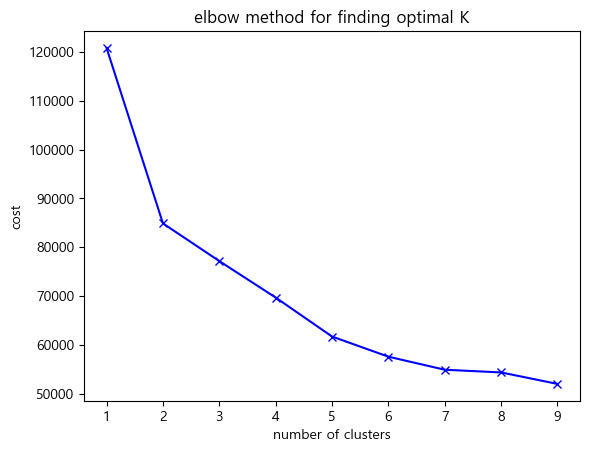

In [101]:
cost = []
K = range(1, 10)
for num in K:
    kmode = KModes(n_clusters = num, n_init = 3)
    kmode.fit_predict(departure)
    cost.append(kmode.cost_)

plt.plot(K, cost, 'bx-')
plt.xlabel('number of clusters')
plt.ylabel('cost')
plt.title('elbow method for finding optimal K')
plt.show()

In [176]:
kmode = KModes(n_clusters = 6, n_init = 3)
clusters = kmode.fit_predict(departure)
departure['clusters'] = clusters

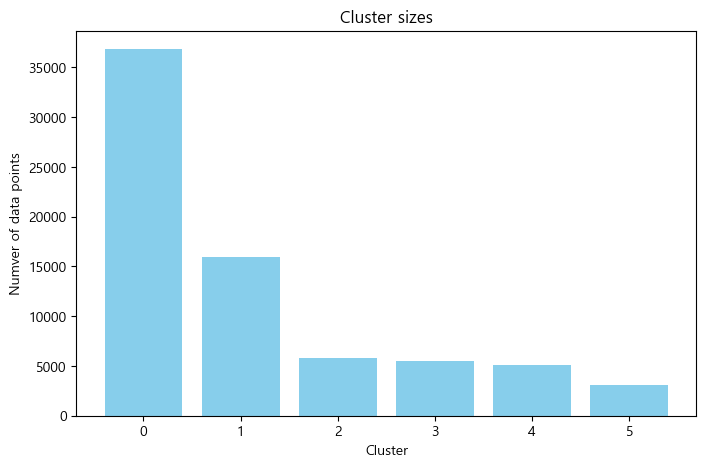

In [177]:
clustersize = departure['clusters'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(clustersize.index,clustersize.values,color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Numver of data points')
plt.title('Cluster sizes')
plt.xticks(clustersize.index)
plt.show()

In [178]:
clustersize

clusters
0    36849
1    15985
2     5802
3     5494
4     5084
5     3054
Name: count, dtype: int64

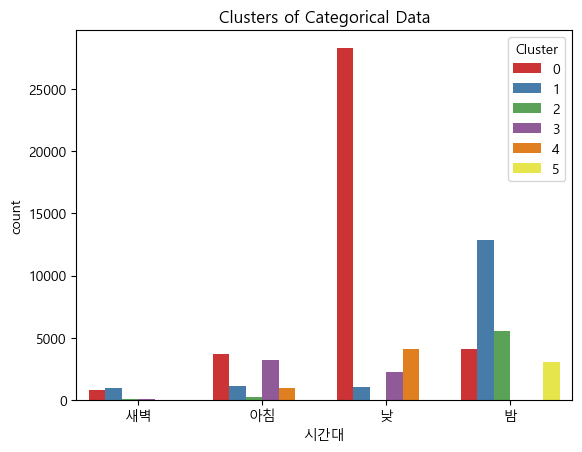

In [105]:
sns.countplot(x='시간대', hue='clusters', data=departure, palette='Set1')
plt.title('Clusters of Categorical Data')
plt.legend(title='Cluster')
plt.show()

In [107]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    print(f"Cluster {cluster} Characteristics:")
    print(cluster_data['시간대'].value_counts())
    print()

Cluster 0 Characteristics:
시간대
낮     28286
밤      4084
아침     3675
새벽      804
Name: count, dtype: int64

Cluster 1 Characteristics:
시간대
밤     12841
아침     1112
낮      1081
새벽      951
Name: count, dtype: int64

Cluster 2 Characteristics:
시간대
밤     5549
아침     205
새벽      48
낮        0
Name: count, dtype: int64

Cluster 3 Characteristics:
시간대
아침    3188
낮     2258
새벽      48
밤        0
Name: count, dtype: int64

Cluster 4 Characteristics:
시간대
낮     4080
아침    1004
새벽       0
밤        0
Name: count, dtype: int64

Cluster 5 Characteristics:
시간대
밤     3049
새벽       5
아침       0
낮        0
Name: count, dtype: int64



In [117]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    print(f"Cluster {cluster} Characteristics:")
    time_counts = cluster_data['시간대'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    print(time_percentages)
    print()

Cluster 0 Characteristics:
시간대
낮     76.761920
밤     11.083069
아침     9.973134
새벽     2.181877
Name: count, dtype: float64

Cluster 1 Characteristics:
시간대
밤     80.331561
아침     6.956522
낮      6.762590
새벽     5.949327
Name: count, dtype: float64

Cluster 2 Characteristics:
시간대
밤     95.639435
아침     3.533264
새벽     0.827301
낮      0.000000
Name: count, dtype: float64

Cluster 3 Characteristics:
시간대
아침    58.026938
낮     41.099381
새벽     0.873680
밤      0.000000
Name: count, dtype: float64

Cluster 4 Characteristics:
시간대
낮     80.25177
아침    19.74823
새벽     0.00000
밤      0.00000
Name: count, dtype: float64

Cluster 5 Characteristics:
시간대
밤     99.83628
새벽     0.16372
아침     0.00000
낮      0.00000
Name: count, dtype: float64



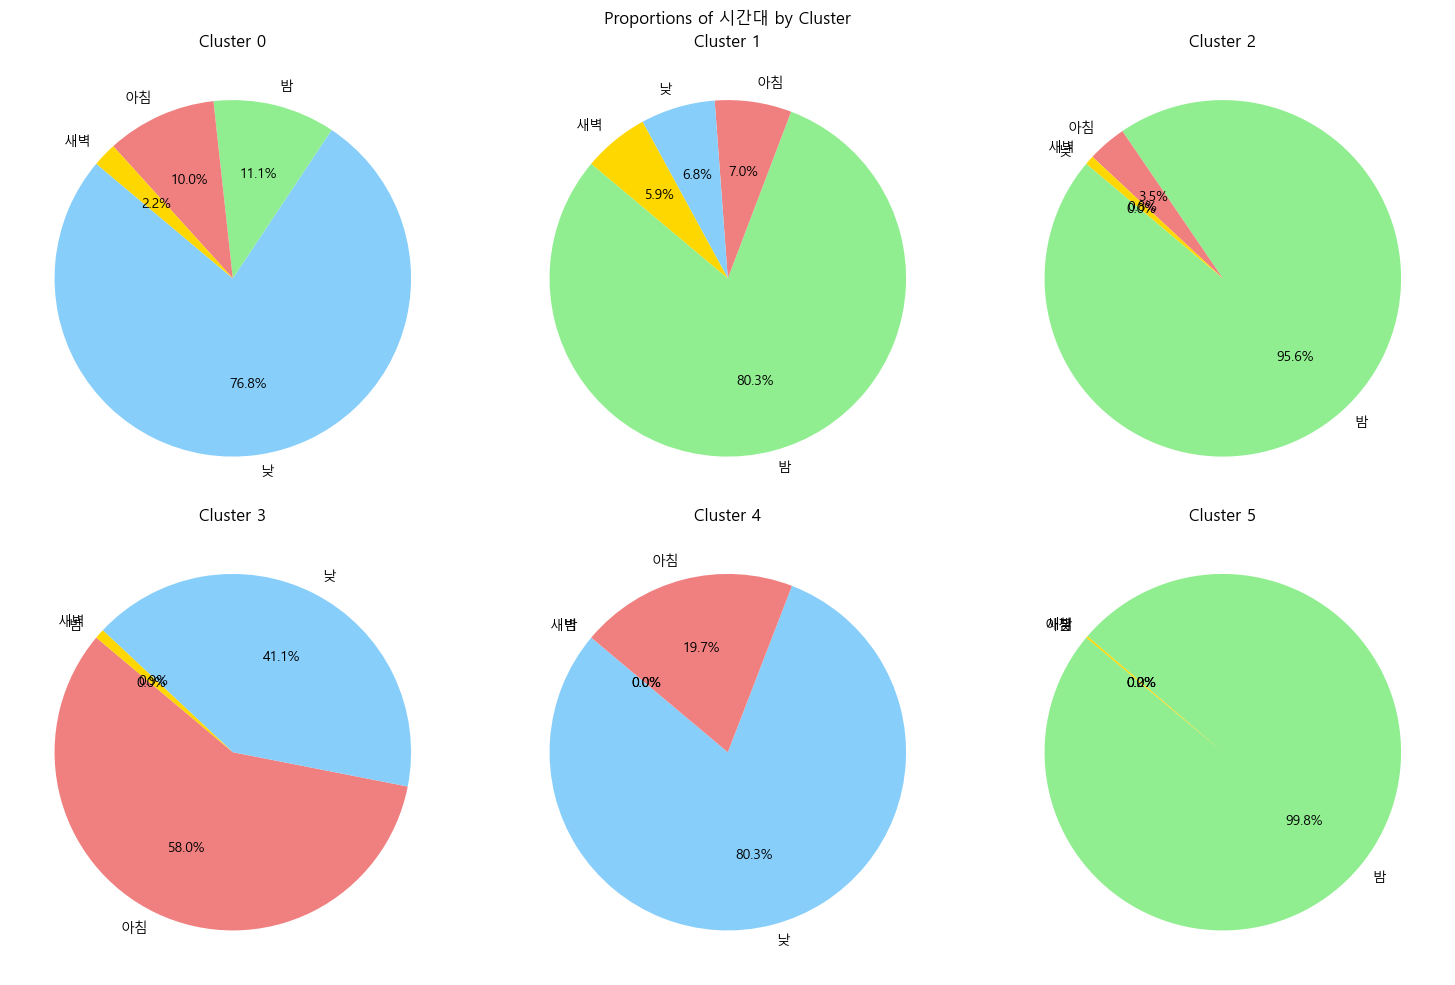

In [131]:
colors = {
    '새벽': 'gold',
    '아침': 'lightcoral',
    '낮': 'lightskyblue',
    '밤': 'lightgreen'
}

fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
fig.suptitle('Proportions of 시간대 by Cluster')

for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    time_counts = cluster_data['시간대'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    
    ax = axs[cluster // 3, cluster % 3]
    ax.pie(time_percentages, labels=time_percentages.index, autopct='%1.1f%%', startangle=140,
           colors=[colors[label] for label in time_percentages.index])
    ax.set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()

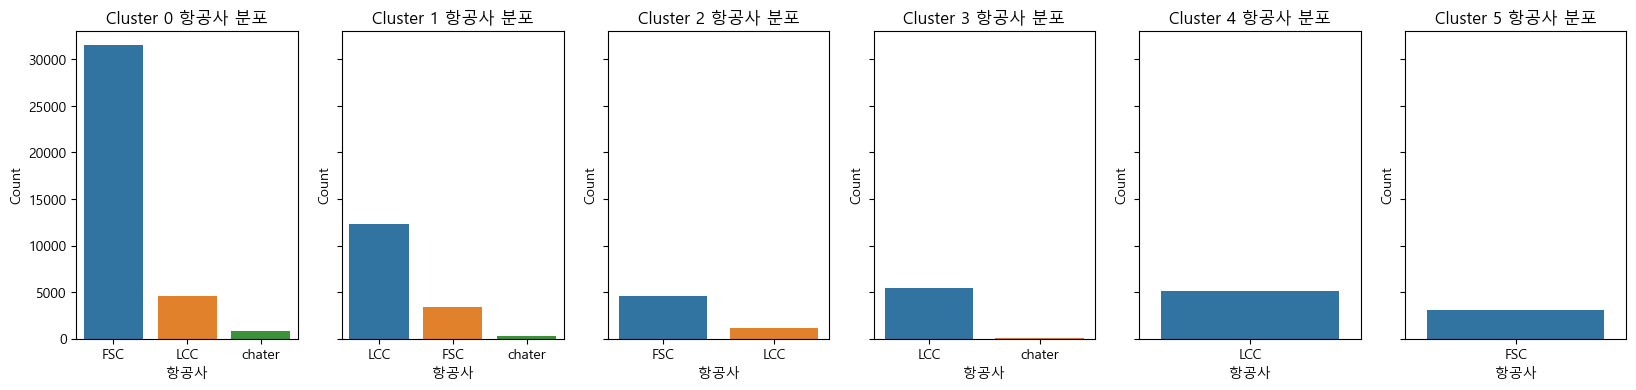

In [111]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4), sharey=True)

for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    sns.countplot(x='항공사', data=cluster_data, ax=axes[cluster])
    axes[cluster].set_title(f'Cluster {cluster} 항공사 분포')
    axes[cluster].set_xlabel('항공사')
    axes[cluster].set_ylabel('Count')

plt.show()

In [112]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    print(f"Cluster {cluster} Characteristics:")
    print(cluster_data['항공사'].value_counts())
    print()

Cluster 0 Characteristics:
항공사
FSC       31503
LCC        4561
chater      785
Name: count, dtype: int64

Cluster 1 Characteristics:
항공사
LCC       12318
FSC        3373
chater      294
Name: count, dtype: int64

Cluster 2 Characteristics:
항공사
FSC    4619
LCC    1183
Name: count, dtype: int64

Cluster 3 Characteristics:
항공사
LCC       5478
chater      16
Name: count, dtype: int64

Cluster 4 Characteristics:
항공사
LCC    5084
Name: count, dtype: int64

Cluster 5 Characteristics:
항공사
FSC    3054
Name: count, dtype: int64



In [118]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    print(f"Cluster {cluster} Characteristics:")
    time_counts = cluster_data['항공사'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    print(time_percentages)
    print()

Cluster 0 Characteristics:
항공사
FSC       85.492144
LCC       12.377541
chater     2.130316
Name: count, dtype: float64

Cluster 1 Characteristics:
항공사
LCC       77.059744
FSC       21.101032
chater     1.839224
Name: count, dtype: float64

Cluster 2 Characteristics:
항공사
FSC    79.610479
LCC    20.389521
Name: count, dtype: float64

Cluster 3 Characteristics:
항공사
LCC       99.708773
chater     0.291227
Name: count, dtype: float64

Cluster 4 Characteristics:
항공사
LCC    100.0
Name: count, dtype: float64

Cluster 5 Characteristics:
항공사
FSC    100.0
Name: count, dtype: float64



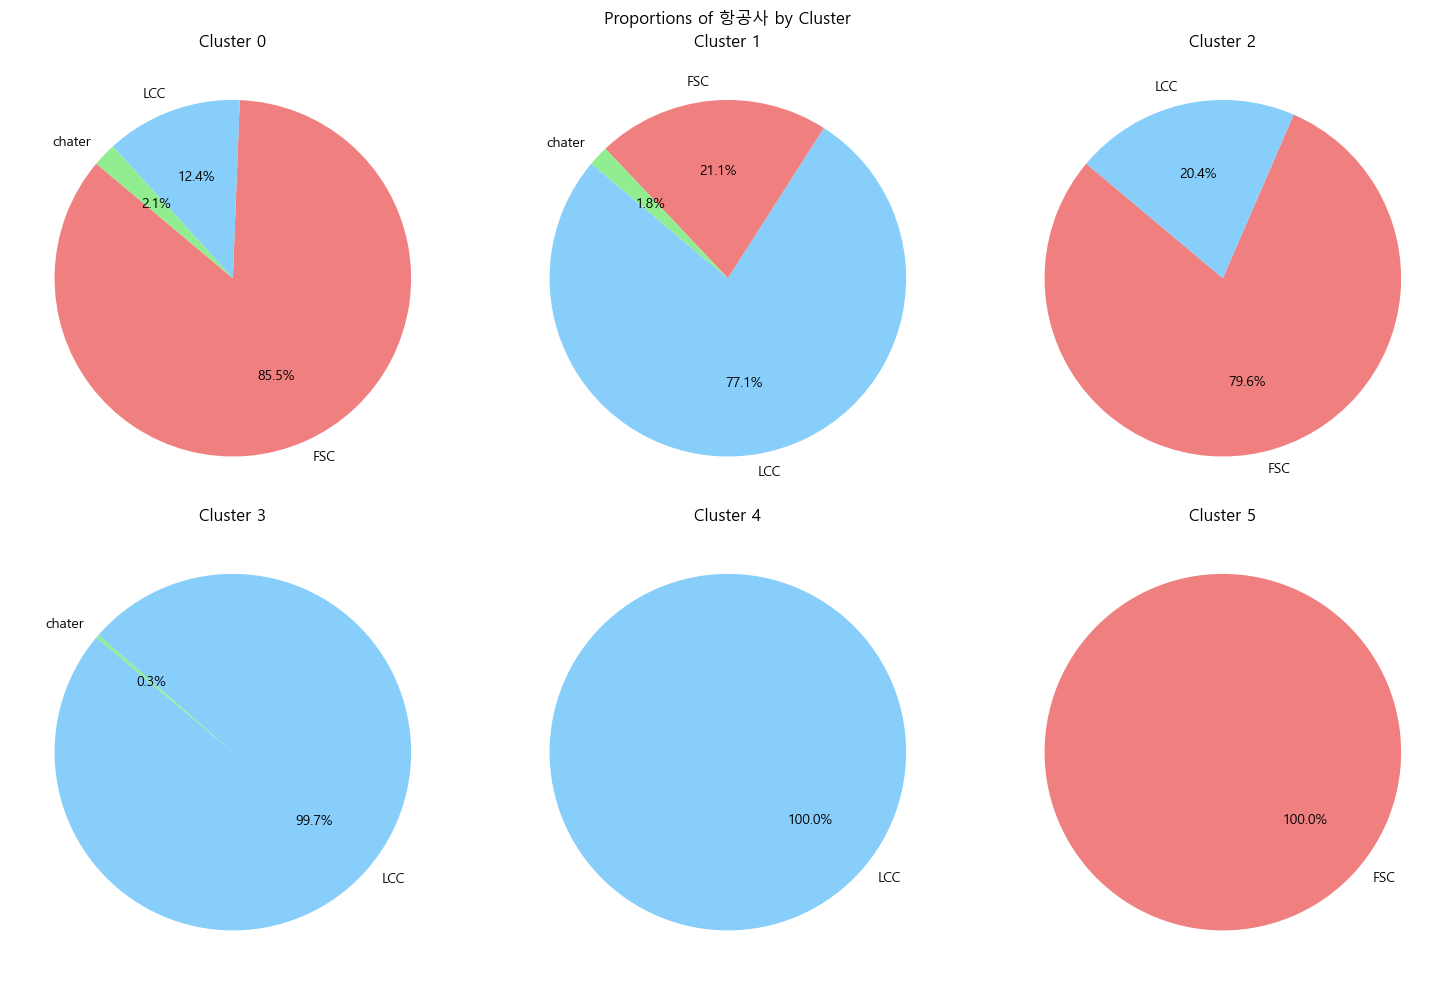

In [132]:
colors = {
    'FSC': 'lightcoral',
    'LCC': 'lightskyblue',
    'chater': 'lightgreen'
}

fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
fig.suptitle('Proportions of 항공사 by Cluster')

for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    time_counts = cluster_data['항공사'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    
    ax = axs[cluster // 3, cluster % 3]
    ax.pie(time_percentages, labels=time_percentages.index, autopct='%1.1f%%', startangle=140,
           colors=[colors[label] for label in time_percentages.index])
    ax.set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()

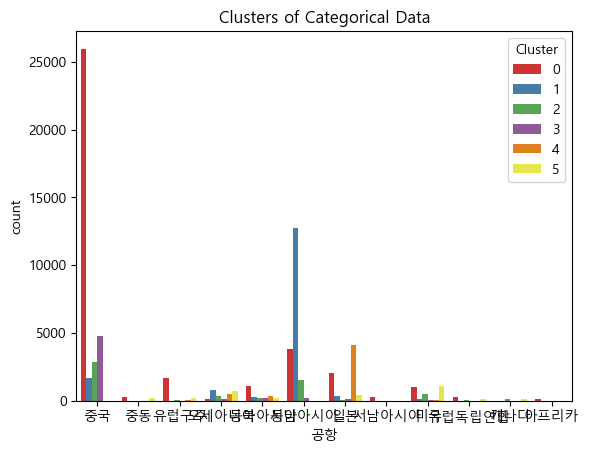

In [113]:
sns.countplot(x='공항', hue='clusters', data=departure, palette='Set1')
plt.title('Clusters of Categorical Data')
plt.legend(title='Cluster')
plt.show()

In [114]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    print(f"Cluster {cluster} Characteristics:")
    print(cluster_data['공항'].value_counts())
    print()

Cluster 0 Characteristics:
공항
중국        25957
동남아시아      3857
일본         2028
유럽구주       1717
동북아시아      1087
미국         1055
중동          317
유럽독립연합      302
서남아시아       251
오세아니아       156
아프리카        120
캐나다           2
Name: count, dtype: int64

Cluster 1 Characteristics:
공항
동남아시아     12710
중국         1701
오세아니아       773
일본          379
동북아시아       283
미국          107
유럽독립연합       22
캐나다           6
유럽구주          4
Name: count, dtype: int64

Cluster 2 Characteristics:
공항
중국        2884
동남아시아     1556
미국         508
오세아니아      330
동북아시아      212
캐나다        136
일본          77
유럽독립연합      40
유럽구주        27
중동          15
아프리카        11
서남아시아        6
Name: count, dtype: int64

Cluster 3 Characteristics:
공항
중국        4810
동북아시아      190
동남아시아      187
일본         164
오세아니아      102
미국          33
유럽구주         6
유럽독립연합       2
Name: count, dtype: int64

Cluster 4 Characteristics:
공항
일본       4101
오세아니아     527
동북아시아     340
미국         85
유럽구주       31
Name: count, dtype: int64

Cluster 5

In [119]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    print(f"Cluster {cluster} Characteristics:")
    time_counts = cluster_data['공항'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    print(time_percentages)
    print()

Cluster 0 Characteristics:
공항
중국        70.441532
동남아시아     10.467041
일본         5.503541
유럽구주       4.659557
동북아시아      2.949877
미국         2.863036
중동         0.860268
유럽독립연합     0.819561
서남아시아      0.681158
오세아니아      0.423349
아프리카       0.325653
캐나다        0.005428
Name: count, dtype: float64

Cluster 1 Characteristics:
공항
동남아시아     79.512043
중국        10.641226
오세아니아      4.835784
일본         2.370973
동북아시아      1.770410
미국         0.669378
유럽독립연합     0.137629
캐나다        0.037535
유럽구주       0.025023
Name: count, dtype: float64

Cluster 2 Characteristics:
공항
중국        49.706998
동남아시아     26.818339
미국         8.755602
오세아니아      5.687694
동북아시아      3.653912
캐나다        2.344019
일본         1.327129
유럽독립연합     0.689417
유럽구주       0.465357
중동         0.258532
아프리카       0.189590
서남아시아      0.103413
Name: count, dtype: float64

Cluster 3 Characteristics:
공항
중국        87.550055
동북아시아      3.458318
동남아시아      3.403713
일본         2.985075
오세아니아      1.856571
미국         0.600655
유럽구주       0.

In [158]:
from matplotlib.cm import get_cmap


C:\Users\akj\AppData\Local\Temp\ipykernel_25140\3017834593.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = get_cmap('tab10')  # 'tab10' 색상 맵 사용 (10가지 색상)


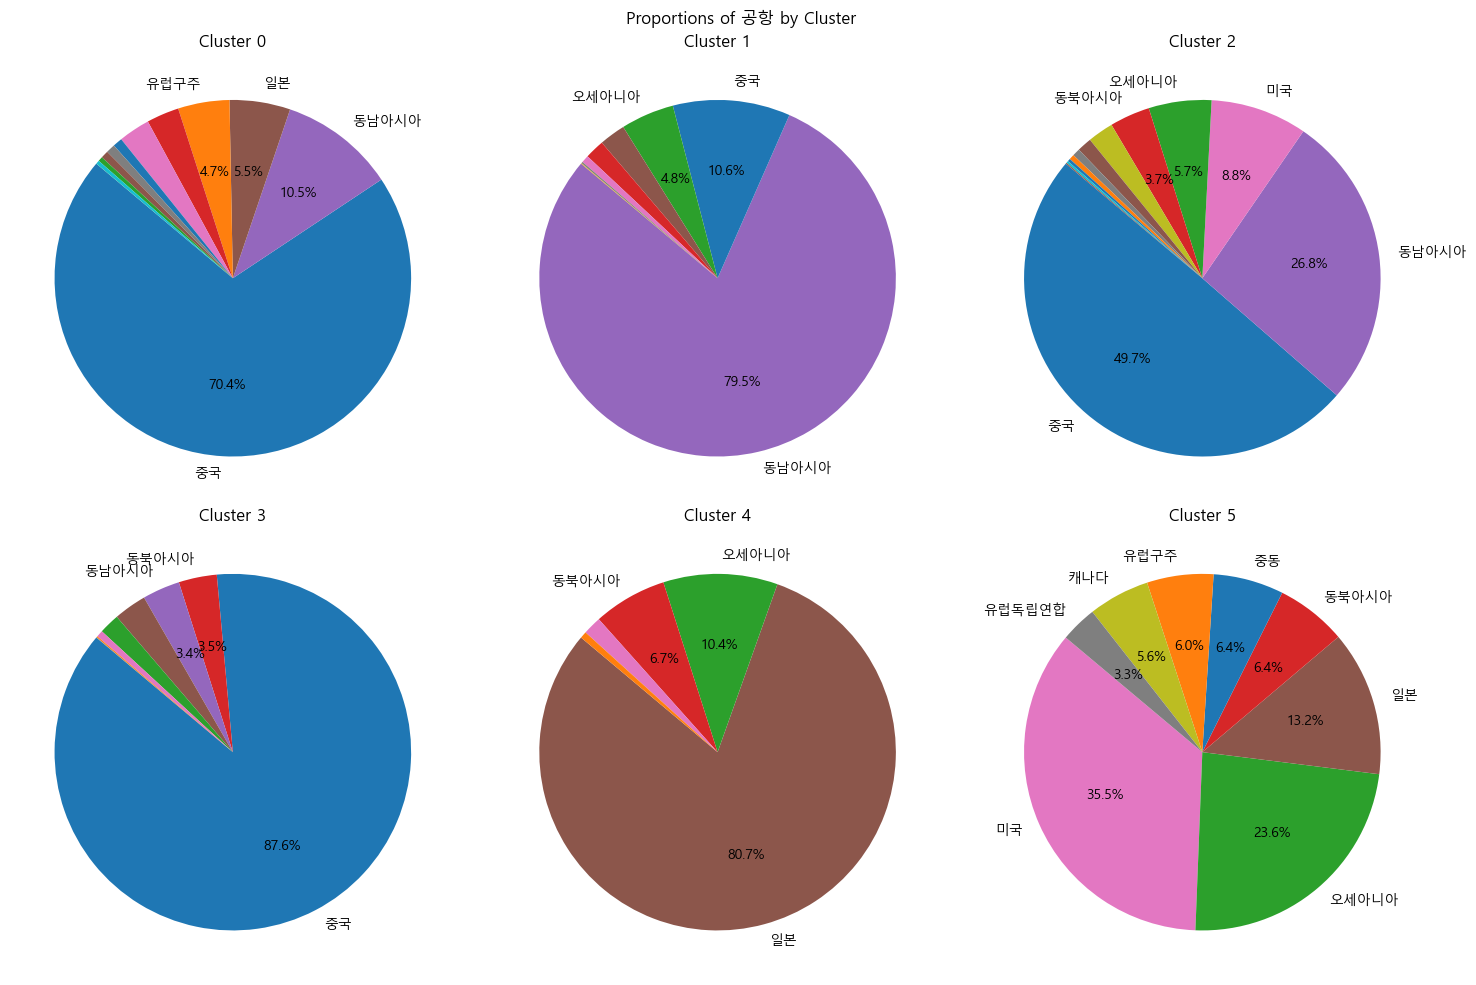

In [180]:
categories = departure['공항'].unique()
color_map = get_cmap('tab10') 

colors = {category: color_map(i / len(categories)) for i, category in enumerate(categories)}

def autopct_format(pct):
    return ('%1.1f%%' % pct) if pct >= 3 else ''

def label_format(label, pct):
    return label if pct >= 3 else ''

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns for 6 clusters
fig.suptitle('Proportions of 공항 by Cluster')

for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    time_counts = cluster_data['공항'].value_counts()
    time_percentages = (time_counts / total_count) * 100

    labels = [label_format(label, pct) for label, pct in zip(time_percentages.index, time_percentages)]
    
    ax = axs[cluster // 3, cluster % 3]
    ax.pie(time_percentages, labels=labels, autopct=autopct_format, startangle=140,
           colors=[colors[label] for label in time_percentages.index])
    ax.set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()

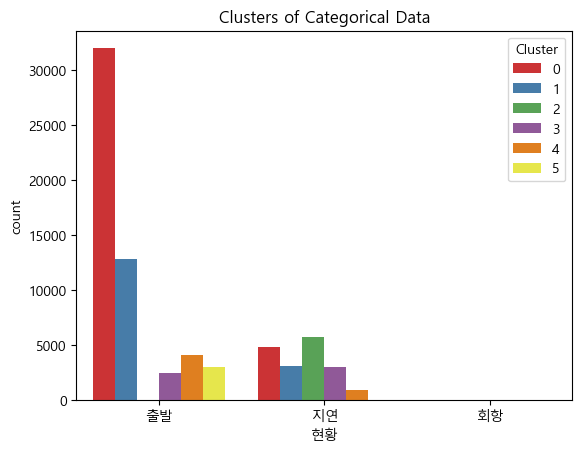

In [115]:
sns.countplot(x='현황', hue='clusters', data=departure, palette='Set1')
plt.title('Clusters of Categorical Data')
plt.legend(title='Cluster')
plt.show()

In [116]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    print(f"Cluster {cluster} Characteristics:")
    print(cluster_data['현황'].value_counts())
    print()

Cluster 0 Characteristics:
현황
출발    32013
지연     4828
회항        8
Name: count, dtype: int64

Cluster 1 Characteristics:
현황
출발    12896
지연     3086
회항        3
Name: count, dtype: int64

Cluster 2 Characteristics:
현황
지연    5801
회항       1
Name: count, dtype: int64

Cluster 3 Characteristics:
현황
지연    3005
출발    2489
Name: count, dtype: int64

Cluster 4 Characteristics:
현황
출발    4153
지연     930
회항       1
Name: count, dtype: int64

Cluster 5 Characteristics:
현황
출발    3054
Name: count, dtype: int64



In [120]:
for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    print(f"Cluster {cluster} Characteristics:")
    time_counts = cluster_data['현황'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    print(time_percentages)
    print()

Cluster 0 Characteristics:
현황
출발    86.876170
지연    13.102119
회항     0.021710
Name: count, dtype: float64

Cluster 1 Characteristics:
현황
출발    80.675633
지연    19.305599
회항     0.018768
Name: count, dtype: float64

Cluster 2 Characteristics:
현황
지연    99.982765
회항     0.017235
Name: count, dtype: float64

Cluster 3 Characteristics:
현황
지연    54.696032
출발    45.303968
Name: count, dtype: float64

Cluster 4 Characteristics:
현황
출발    81.687648
지연    18.292683
회항     0.019670
Name: count, dtype: float64

Cluster 5 Characteristics:
현황
출발    100.0
Name: count, dtype: float64



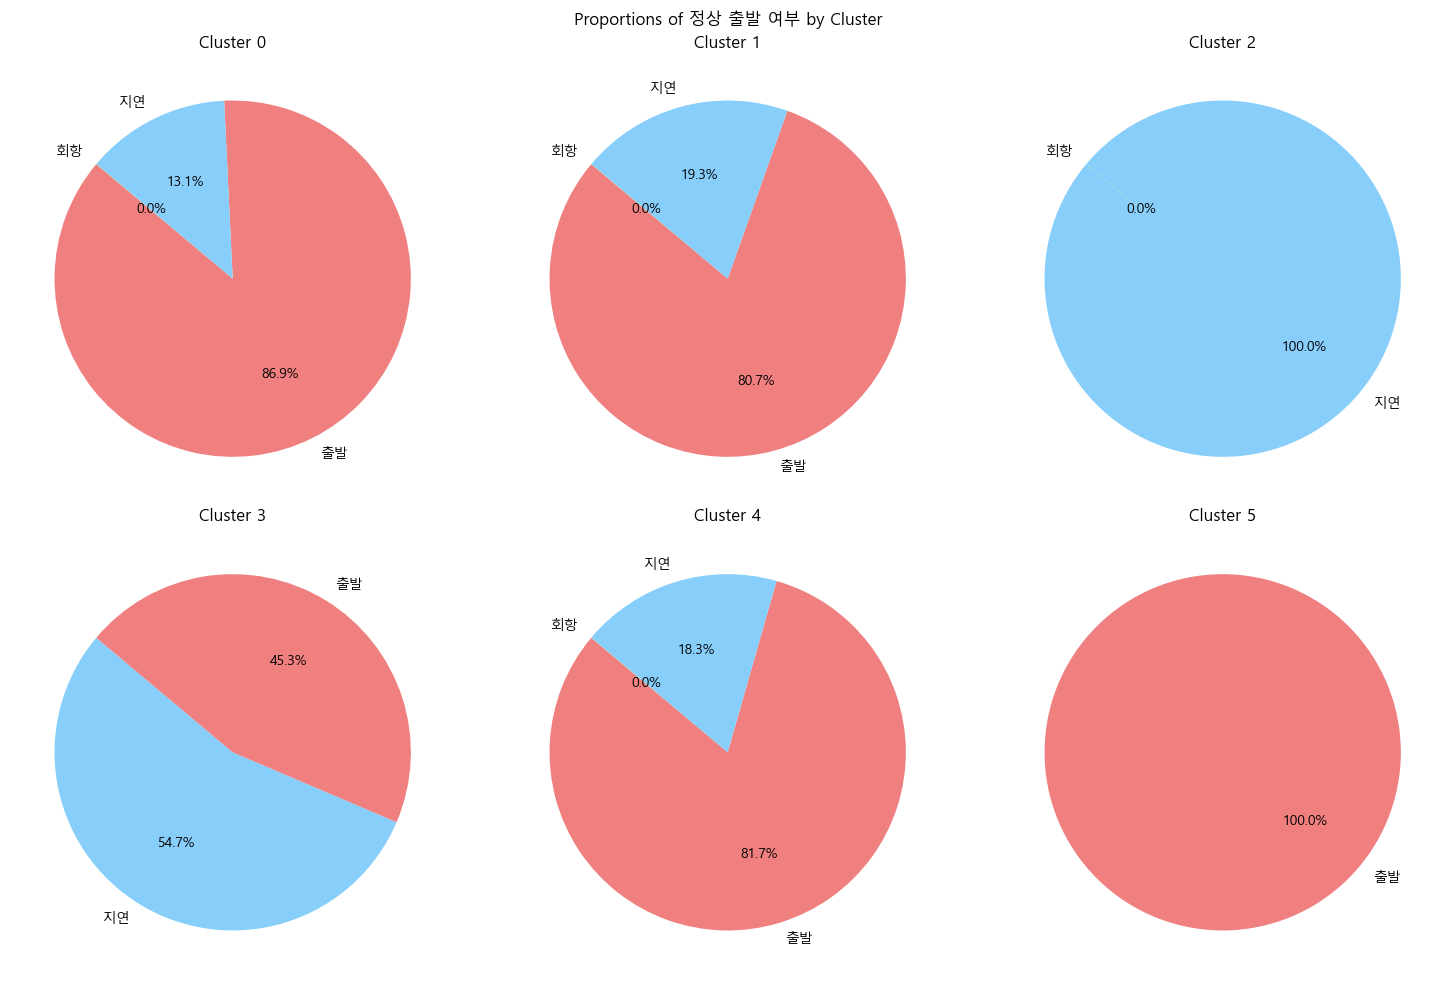

In [133]:
colors = {
    '출발': 'lightcoral',
    '지연': 'lightskyblue',
    '회항': 'lightgreen'
}

fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
fig.suptitle('Proportions of 정상 출발 여부 by Cluster')

for cluster in range(6):
    cluster_data = departure[departure['clusters'] == cluster]
    total_count = len(cluster_data)
    time_counts = cluster_data['현황'].value_counts()
    time_percentages = (time_counts / total_count) * 100
    
    ax = axs[cluster // 3, cluster % 3]
    ax.pie(time_percentages, labels=time_percentages.index, autopct='%1.1f%%', startangle=140,
           colors=[colors[label] for label in time_percentages.index])
    ax.set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()